In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


house_df_org = pd.read_csv('../data/house_price.csv')
house_df = house_df_org.copy()  # 원본 보호
house_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


In [4]:
# 전체 데이터 구조 파악
print(f"데이터 세트의 Shape : {house_df.shape}")
print(f"피처의 데이터 타입 개수:\n {house_df.dtypes.value_counts()}")

데이터 세트의 Shape : (1460, 81)
피처의 데이터 타입 개수:
 str        43
int64      35
float64     3
Name: count, dtype: int64


In [5]:
# 피처의 Null 개수 확인
isnull_series = house_df.isna().sum()
isnull_series[isnull_series>0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

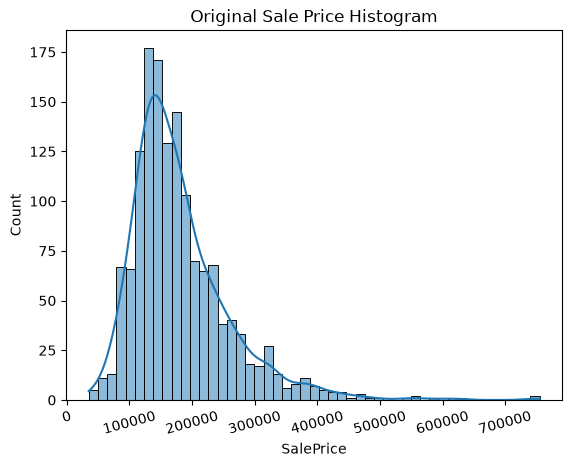

In [8]:
# Label 분포 확인
plt.title("Original Sale Price Histogram")
plt.xticks(rotation=15)
sns.histplot(house_df["SalePrice"], kde=True)
plt.show()

In [6]:
# SalePrice 로그 변환
original_SalePrice = house_df['SalePrice']  # 원래 가격을 임시 저장
house_df['SalePrice'] = np.log1p(house_df['SalePrice']) # 로그 변환


# Null 이 너무 많은 컬럼들과 불필요한 컬럼 삭제
house_df.drop(['Id','PoolQC' , 'MiscFeature', 'Alley', 'Fence','FireplaceQu'], axis=1 , inplace=True)


In [7]:

# Drop 하지 않는 숫자형 Null컬럼들은 평균값으로 대체
# house_df.fillna(house_df.mean(),inplace=True)
# dtype : str 인 피처는 평균을 못 구한다.
# dtype이 str인 피처를 제외하고 평균으로 채워라
# 숫자 타입 피처 추출
num_columns = house_df.dtypes[house_df.dtypes != 'str'].index.to_list()
house_df[num_columns] = house_df[num_columns].fillna(house_df[num_columns].mean())
# Null 값이 있는 피처명과 타입을 추출
null_column_count = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('## Null 피처의 Type :\n', house_df.dtypes[null_column_count.index])


## Null 피처의 Type :
 MasVnrType      str
BsmtQual        str
BsmtCond        str
BsmtExposure    str
BsmtFinType1    str
BsmtFinType2    str
Electrical      str
GarageType      str
GarageFinish    str
GarageQual      str
GarageCond      str
dtype: object


In [8]:
house_df = house_df_org.copy() # 원본 보호
# SalePrice 로그 변환
original_SalePrice = house_df['SalePrice'] # 원래 가격을 임시 저장
house_df['SalePrice'] = np.log1p(house_df['SalePrice']) # 로그 변환


# Null 이 너무 많은 컬럼들과 불필요한 컬럼 삭제
house_df.drop(['Id','PoolQC' , 'MiscFeature', 'Alley', 'Fence','FireplaceQu'], axis=1 , inplace=True)
# Drop 하지 않는 숫자형 Null컬럼들은 평균값으로 대체
# house_df.fillna(house_df.mean(),inplace=True)
house_df[num_columns] = house_df[num_columns].fillna(house_df[num_columns].mean())


# Null 값이 있는 피처명과 타입을 추출
null_column_count = house_df.isnull().sum()[house_df.isnull().sum() > 0]
print('## Null 피처의 Type :\n', house_df.dtypes[null_column_count.index])


## Null 피처의 Type :
 MasVnrType      str
BsmtQual        str
BsmtCond        str
BsmtExposure    str
BsmtFinType1    str
BsmtFinType2    str
Electrical      str
GarageType      str
GarageFinish    str
GarageQual      str
GarageCond      str
dtype: object


In [9]:
house_df[num_columns].head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,12.247699
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,12.109016
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,12.317171
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,11.849405
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,12.429220


In [10]:
house_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 75 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   str    
 2   LotFrontage    1460 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   str    
 5   LotShape       1460 non-null   str    
 6   LandContour    1460 non-null   str    
 7   Utilities      1460 non-null   str    
 8   LotConfig      1460 non-null   str    
 9   LandSlope      1460 non-null   str    
 10  Neighborhood   1460 non-null   str    
 11  Condition1     1460 non-null   str    
 12  Condition2     1460 non-null   str    
 13  BldgType       1460 non-null   str    
 14  HouseStyle     1460 non-null   str    
 15  OverallQual    1460 non-null   int64  
 16  OverallCond    1460 non-null   int64  
 17  YearBuilt      1460 non-null   int64  
 18  YearRemodAdd   1460

In [15]:
# 문자열 타입의 NaN 개수 : NaN 발생하는 경우 언제? => 계산할 때. str은 계산x
# house_df.isna().sum()   # 피처별 NaN 개수 -> 시리즈
null_columns = house_df.isna().sum()[house_df.isna().sum()>0]  # Series라 boolean indexing 가능
num_columns

['MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

In [12]:
house_df.dtypes.value_counts()

str        38
int64      33
float64     4
Name: count, dtype: int64